<a href="https://colab.research.google.com/github/ctrl-ajit/Face-Shape-Classifier-using-CNN/blob/main/face_shape_v3_clean_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Shape Classification with Explainable AI (v3 - Clean)
### Gender-Conditioned Pipeline + VGG16 Transfer Learning + Grad-CAM + Style Recommendations

Clean rebuild incorporating every fix found so far:
- Truncated image handling
- "ractangle" typo fix
- OpenCV Haar Cascade face cropping (no mediapipe dependency issues)
- **VGG16 transfer learning** (published benchmarks show 80-91% accuracy on this task, vs ~50% with MobileNetV2 alone)
- Two-phase training (frozen base, then fine-tuning) with conservative settings to avoid overfitting
- Checkpointing throughout

**Before running:** Runtime → Change runtime type → **T4 GPU**

Run top to bottom, in order, without skipping.

## 0. Fix Colab's OpenCV (run this FIRST, before anything else)

Colab sometimes ships a broken OpenCV build missing `CascadeClassifier`. This forces
a known-good version. **After running this cell, you MUST restart the runtime**
(Runtime → Restart runtime) before continuing to Cell 1 below — a plain re-run
is not enough, the broken version stays cached in memory otherwise.

In [ ]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python -q
!pip install opencv-python-headless==4.10.0.84 -q

print("Installed. NOW GO TO: Runtime -> Restart runtime, then continue from Cell 1 below.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.5 MB/s eta 0:00:00
Installed. NOW GO TO: Runtime -> Restart runtime, then continue from Cell 1 below.


## 1. Setup

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

print("TF version:", tf.__version__)
print("cv2 version:", cv2.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
cv2 version: 4.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/face_shape_project'
FEMALE_DATA = os.path.join(BASE_PATH, 'female_data')
MALE_DATA = os.path.join(BASE_PATH, 'male_data')

print(os.listdir(BASE_PATH))

Mounted at /content/drive
['male_data', 'female_data', 'cropped_faces', 'gender_model.h5', 'female_shape_model_checkpoint.h5', 'female_shape_model.h5', 'male_shape_model_checkpoint.h5', 'male_shape_model.h5', 'gender_model_checkpoint.h5']


## 3. Index Files & Fix Known Label Typo

In [ ]:
def index_folder(root_dir, gender_label):
    records = []
    for split_folder in os.listdir(root_dir):
        split_path = os.path.join(root_dir, split_folder)
        if not os.path.isdir(split_path):
            continue
        for class_name in sorted(os.listdir(split_path)):
            class_dir = os.path.join(split_path, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    records.append({
                        'filepath': os.path.join(class_dir, fname),
                        'gender': gender_label,
                        'face_shape': class_name.lower().strip()
                    })
    return records

female_records = index_folder(FEMALE_DATA, 'female')
male_records = index_folder(MALE_DATA, 'male')

df = pd.DataFrame(female_records + male_records)
df['face_shape'] = df['face_shape'].replace('ractangle', 'rectangle')

print(df.groupby(['gender', 'face_shape']).size())

gender  face_shape
female  heart         1000
        oblong        1000
        oval          1000
        round         1000
        square        1000
male    oval           346
        rectangle      305
        round          340
        square         320
dtype: int64


In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

CROPPED_DIR = os.path.join(BASE_PATH, 'cropped_faces')
os.makedirs(CROPPED_DIR, exist_ok=True)

def crop_face(filepath, output_path, margin_top=0.3, margin_side=0.3, margin_bottom=0.45):
    img = cv2.imread(filepath)
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        return False
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    img_h, img_w = img.shape[:2]
    mx, mt, mb = int(w * margin_side), int(h * margin_top), int(h * margin_bottom)
    x1, y1 = max(0, x - mx), max(0, y - mt)
    x2, y2 = min(img_w, x + w + mx), min(img_h, y + h + mb)
    cropped = img[y1:y2, x1:x2]
    if cropped.size == 0:
        return False
    cv2.imwrite(output_path, cropped)
    return True

new_paths = []
crop_failed = 0
for idx, row in df.iterrows():
    class_folder = os.path.join(CROPPED_DIR, row['gender'], row['face_shape'])
    os.makedirs(class_folder, exist_ok=True)
    out_path = os.path.join(class_folder, f"{idx}.jpg")
    if os.path.exists(out_path):
        new_paths.append(out_path)
        continue
    success = crop_face(row['filepath'], out_path)
    new_paths.append(out_path if success else None)
    if not success:
        crop_failed += 1

df['cropped_filepath'] = new_paths
print(f"Failed to crop: {crop_failed}")
df = df[df['cropped_filepath'].notna()].reset_index(drop=True)
print(f"Remaining: {len(df)}")

Failed to crop: 0
Remaining: 6311


In [ ]:
df['strata'] = df['gender'] + '_' + df['face_shape']

import shutil
LOCAL_CROPPED_DIR = '/content/cropped_faces_local'
shutil.copytree(CROPPED_DIR, LOCAL_CROPPED_DIR, dirs_exist_ok=True)

df['cropped_filepath'] = df['cropped_filepath'].str.replace(CROPPED_DIR, LOCAL_CROPPED_DIR, regex=False)

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['strata'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['strata'], random_state=42)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
print("Sample path:", train_df['cropped_filepath'].iloc[0])

Train: 4417  Val: 947  Test: 947
Sample path: /content/cropped_faces_local/female/oblong/2209.jpg


## 4. Face Cropping (OpenCV Haar Cascade)

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

CROPPED_DIR = os.path.join(BASE_PATH, 'cropped_faces')
os.makedirs(CROPPED_DIR, exist_ok=True)

def crop_face(filepath, output_path, margin_top=0.3, margin_side=0.3, margin_bottom=0.45):
    img = cv2.imread(filepath)
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    if len(faces) == 0:
        return False
    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    img_h, img_w = img.shape[:2]
    mx = int(w * margin_side)
    mt = int(h * margin_top)
    mb = int(h * margin_bottom)
    x1, y1 = max(0, x - mx), max(0, y - mt)
    x2, y2 = min(img_w, x + w + mx), min(img_h, y + h + mb)
    cropped = img[y1:y2, x1:x2]
    if cropped.size == 0:
        return False
    cv2.imwrite(output_path, cropped)
    return True

In [ ]:
new_paths = []
crop_failed = 0

for idx, row in df.iterrows():
    class_folder = os.path.join(CROPPED_DIR, row['gender'], row['face_shape'])
    os.makedirs(class_folder, exist_ok=True)
    out_path = os.path.join(class_folder, f"{idx}.jpg")

    if os.path.exists(out_path):
        new_paths.append(out_path)
        continue

    success = crop_face(row['filepath'], out_path)
    new_paths.append(out_path if success else None)
    if not success:
        crop_failed += 1

df['cropped_filepath'] = df['cropped_filepath'].str.replace(CROPPED_DIR, LOCAL_CROPPED_DIR, regex=False)

# Re-run the split so train_df/val_df/test_df pick up the new local paths
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['strata'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['strata'], random_state=42)

print("Sample path check:", train_df['cropped_filepath'].iloc[0])

Sample path check: /content/cropped_faces_local/female/oblong/345.jpg


## 5. Train/Val/Test Split

In [ ]:
df['strata'] = df['gender'] + '_' + df['face_shape']

train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['strata'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['strata'], random_state=42)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
train_df['strata'].value_counts()

Train: 4417  Val: 947  Test: 947


,count
strata,
female_oblong,700
female_heart,700
female_square,700
female_round,700
female_oval,700
male_oval,242
male_round,238
male_square,224
male_rectangle,213


## 6. Shared Functions: Generators + VGG16 Transfer Model + Fine-tuning

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def make_generator(dataframe, label_col, img_size=IMG_SIZE, batch_size=BATCH_SIZE, augment=False, shuffle=True):
    gen = ImageDataGenerator(rescale=1/255., rotation_range=15, width_shift_range=0.1,
                              height_shift_range=0.1, horizontal_flip=True, zoom_range=0.1) if augment else ImageDataGenerator(rescale=1/255.)
    return gen.flow_from_dataframe(dataframe, x_col='cropped_filepath', y_col=label_col,
                                     target_size=(img_size, img_size), batch_size=batch_size,
                                     class_mode='categorical', shuffle=shuffle)

def overlay_gradcam(filepath, model, class_labels, img_size=224, alpha=0.4):
    base_layer = next(l for l in model.layers if 'vgg16' in l.name.lower())
    conv_layer = base_layer.get_layer('block5_conv3')
    base_grad_model = tf.keras.models.Model(base_layer.input, [conv_layer.output, base_layer.output])
    idx = model.layers.index(base_layer)
    head_layers = model.layers[idx + 1:]

    img = cv2.cvtColor(cv2.imread(filepath), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_array = tf.convert_to_tensor(np.expand_dims(img_resized / 255., axis=0), dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_output, base_output = base_grad_model(img_array)
        tape.watch(conv_output)
        x = base_output
        for layer in head_layers:
            x = layer(x, training=False)
        pred_index = tf.argmax(x[0])
        class_channel = x[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.maximum(tf.squeeze(heatmap), 0) / (tf.reduce_max(heatmap) + 1e-8)
    heatmap_resized = cv2.resize(heatmap.numpy(), (img_size, img_size))
    heatmap_colored = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlaid = cv2.addWeighted(img_resized, 1 - alpha, heatmap_colored, alpha, 0)
    return img_resized, overlaid, class_labels[int(pred_index)]

print("Functions ready (corrected Grad-CAM).")

Functions ready (corrected Grad-CAM).


In [ ]:
import shutil

LOCAL_CROPPED_DIR = '/content/cropped_faces_local'

if not os.path.exists(LOCAL_CROPPED_DIR):
    print("Copying cropped faces to local disk (one-time, may take a few minutes)...")
    shutil.copytree(CROPPED_DIR, LOCAL_CROPPED_DIR)
    print("Done.")
else:
    print("Already copied.")

Already copied.


## 7. Gender Classifier

In [ ]:
gender_train_gen = make_generator(train_df, 'gender', augment=True)
gender_val_gen = make_generator(val_df, 'gender', shuffle=False)
gender_test_gen = make_generator(test_df, 'gender', shuffle=False)

gender_model, gender_base = build_transfer_model(num_classes=2)

gender_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(BASE_PATH, 'gender_model_checkpoint.h5'),
    save_best_only=True, monitor='val_accuracy'
)

gender_history = gender_model.fit(
    gender_train_gen,
    validation_data=gender_val_gen,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
        gender_checkpoint_cb
    ]
)

Found 4417 validated image filenames belonging to 2 classes.
Found 947 validated image filenames belonging to 2 classes.
Found 947 validated image filenames belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.8086 - loss: 0.4458

139/139 ━━━━━━━━━━━━━━━━━━━━ 115s 717ms/step - accuracy: 0.8884 - loss: 0.2624 - val_accuracy: 0.9525 - val_loss: 0.1041
Epoch 2/15
 67/139 ━━━━━━━━━━━━━━━━━━━━ 38s 535ms/step - accuracy: 0.9557 - loss: 0.1090

KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
print("GPU devices:", tf.config.list_physical_devices('GPU'))

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
test_loss, test_acc = gender_model.evaluate(gender_test_gen)
print(f"Gender classifier test accuracy: {test_acc:.4f}")
gender_model.save(os.path.join(BASE_PATH, 'gender_model.h5'))

30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 598ms/step - accuracy: 0.9947 - loss: 0.0093


Gender classifier test accuracy: 0.9947


In [ ]:
female_shape_model = tf.keras.models.load_model(os.path.join(BASE_PATH, 'female_shape_model.h5'))
female_base = female_shape_model.get_layer([l.name for l in female_shape_model.layers if 'vgg16' in l.name][0])

female_train = train_df[train_df['gender'] == 'female']
female_val = val_df[val_df['gender'] == 'female']
female_test = test_df[test_df['gender'] == 'female']
female_labels = sorted(female_train['face_shape'].unique())

female_train_gen = make_generator(female_train, 'face_shape', augment=True)
female_val_gen = make_generator(female_val, 'face_shape', shuffle=False)
female_test_gen = make_generator(female_test, 'face_shape', shuffle=False)

print("Reloaded. Verifying accuracy:")
female_shape_model.evaluate(female_test_gen)

Found 3500 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.
Reloaded. Verifying accuracy:
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 623ms/step - accuracy: 0.7107 - loss: 0.8156


[0.8156450390815735, 0.7106666564941406]

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_indices = female_train_gen.class_indices
y_train_labels = female_train_gen.classes

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weights = dict(zip(np.unique(y_train_labels), class_weights_array))

class_weights[class_indices['oval']] *= 1.5

print("Class indices:", class_indices)
print("Class weights:", class_weights)


Class indices: {'heart': 0, 'oblong': 1, 'oval': 2, 'round': 3, 'square': 4}
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.5), np.int64(3): np.float64(1.0), np.int64(4): np.float64(1.0)}


## 8. Prepare Gender-Specific Splits

In [ ]:
female_train = train_df[train_df['gender'] == 'female']
female_val = val_df[val_df['gender'] == 'female']
female_test = test_df[test_df['gender'] == 'female']

male_train = train_df[train_df['gender'] == 'male']
male_val = val_df[val_df['gender'] == 'male']
male_test = test_df[test_df['gender'] == 'male']

female_labels = sorted(female_train['face_shape'].unique())
male_labels = sorted(male_train['face_shape'].unique())

print("Female classes:", female_labels)
print("Male classes:", male_labels)

Female classes: ['heart', 'oblong', 'oval', 'round', 'square']
Male classes: ['oval', 'rectangle', 'round', 'square']


## 9. Female Face Shape Classifier

**Phase 1 (frozen base):**

In [ ]:
female_train_gen = make_generator(female_train, 'face_shape', augment=True)
female_val_gen = make_generator(female_val, 'face_shape', shuffle=False)
female_test_gen = make_generator(female_test, 'face_shape', shuffle=False)

female_shape_model, female_base = build_transfer_model(num_classes=len(female_labels))

female_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(BASE_PATH, 'female_shape_model_checkpoint.h5'),
    save_best_only=True, monitor='val_accuracy'
)

female_history = female_shape_model.fit(
    female_train_gen,
    validation_data=female_val_gen,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        female_checkpoint_cb
    ]
)

Found 3485 validated image filenames belonging to 5 classes.
Found 746 validated image filenames belonging to 5 classes.
Found 748 validated image filenames belonging to 5 classes.
Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.2143 - loss: 1.7622

109/109 ━━━━━━━━━━━━━━━━━━━━ 89s 788ms/step - accuracy: 0.2189 - loss: 1.6740 - val_accuracy: 0.3458 - val_loss: 1.5688
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.2613 - loss: 1.5902

109/109 ━━━━━━━━━━━━━━━━━━━━ 120s 603ms/step - accuracy: 0.2588 - loss: 1.5832 - val_accuracy: 0.3887 - val_loss: 1.5345
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 63s 580ms/step - accuracy: 0.2826 - loss: 1.5570 - val_accuracy: 0.3592 - val_loss: 1.4931
Epoch 4/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.3125 - loss: 1.5237

109/109 ━━━━━━━━━━━━━━━━━━━━ 67s 609ms/step - accuracy: 0.3073 - loss: 1.5254 - val_accuracy: 0.4330 - val_loss: 1.4620
Epoch 5/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 66s 605ms/step - accuracy: 0.3260 - loss: 1.5005 - val_accuracy: 0.4290 - val_loss: 1.4124
Epoch 6/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.3344 - loss: 1.4951

109/109 ━━━━━━━━━━━━━━━━━━━━ 66s 609ms/step - accuracy: 0.3340 - loss: 1.4846 - val_accuracy: 0.4410 - val_loss: 1.3911
Epoch 7/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.3463 - loss: 1.4815

109/109 ━━━━━━━━━━━━━━━━━━━━ 69s 627ms/step - accuracy: 0.3466 - loss: 1.4770 - val_accuracy: 0.4611 - val_loss: 1.3665
Epoch 8/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.3730 - loss: 1.4408

109/109 ━━━━━━━━━━━━━━━━━━━━ 81s 617ms/step - accuracy: 0.3785 - loss: 1.4460 - val_accuracy: 0.4839 - val_loss: 1.3549
Epoch 9/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 66s 606ms/step - accuracy: 0.3704 - loss: 1.4300 - val_accuracy: 0.4745 - val_loss: 1.3219
Epoch 10/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 64s 586ms/step - accuracy: 0.3928 - loss: 1.4161 - val_accuracy: 0.4732 - val_loss: 1.2940
Epoch 11/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.3883 - loss: 1.4030

109/109 ━━━━━━━━━━━━━━━━━━━━ 67s 613ms/step - accuracy: 0.3908 - loss: 1.4055 - val_accuracy: 0.4933 - val_loss: 1.3049
Epoch 12/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.3946 - loss: 1.3948

109/109 ━━━━━━━━━━━━━━━━━━━━ 68s 622ms/step - accuracy: 0.4017 - loss: 1.3810 - val_accuracy: 0.5107 - val_loss: 1.2805
Epoch 13/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.4172 - loss: 1.3705

109/109 ━━━━━━━━━━━━━━━━━━━━ 67s 618ms/step - accuracy: 0.4181 - loss: 1.3683 - val_accuracy: 0.5523 - val_loss: 1.2409
Epoch 14/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 65s 597ms/step - accuracy: 0.4212 - loss: 1.3618 - val_accuracy: 0.5402 - val_loss: 1.2561
Epoch 15/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 63s 575ms/step - accuracy: 0.4238 - loss: 1.3570 - val_accuracy: 0.5282 - val_loss: 1.2460


**Phase 2 (fine-tune last few VGG16 conv layers, conservative settings):**

In [ ]:
female_finetune_history = unfreeze_and_finetune(
    female_shape_model, female_base, female_train_gen, female_val_gen,
    unfreeze_layers=4, epochs=20,
    checkpoint_path=os.path.join(BASE_PATH, 'female_shape_model_checkpoint.h5')
)

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.3997 - loss: 1.3658

109/109 ━━━━━━━━━━━━━━━━━━━━ 86s 712ms/step - accuracy: 0.4235 - loss: 1.3405 - val_accuracy: 0.5576 - val_loss: 1.1856
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 68s 623ms/step - accuracy: 0.4545 - loss: 1.3020 - val_accuracy: 0.5576 - val_loss: 1.1586
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.4550 - loss: 1.2907

109/109 ━━━━━━━━━━━━━━━━━━━━ 67s 614ms/step - accuracy: 0.4582 - loss: 1.2876 - val_accuracy: 0.5630 - val_loss: 1.1433
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.4926 - loss: 1.2319

109/109 ━━━━━━━━━━━━━━━━━━━━ 72s 658ms/step - accuracy: 0.4809 - loss: 1.2524 - val_accuracy: 0.5751 - val_loss: 1.1325
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.4831 - loss: 1.2637

109/109 ━━━━━━━━━━━━━━━━━━━━ 76s 690ms/step - accuracy: 0.4938 - loss: 1.2444 - val_accuracy: 0.5845 - val_loss: 1.1037
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.4898 - loss: 1.2381

...

109/109 ━━━━━━━━━━━━━━━━━━━━ 69s 635ms/step - accuracy: 0.5194 - loss: 1.1697 - val_accuracy: 0.6354 - val_loss: 1.0299
Epoch 12/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 67s 611ms/step - accuracy: 0.5374 - loss: 1.1412 - val_accuracy: 0.6220 - val_loss: 1.0160
Epoch 13/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 63s 576ms/step - accuracy: 0.5420 - loss: 1.1377 - val_accuracy: 0.6287 - val_loss: 1.0034
Epoch 14/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 63s 580ms/step - accuracy: 0.5406 - loss: 1.1074 - val_accuracy: 0.6260 - val_loss: 0.9919
Epoch 15/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 65s 589ms/step - accuracy: 0.5403 - loss: 1.1037 - val_accuracy: 0.6354 - val_loss: 0.9815
Epoch 16/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.5675 - loss: 1.0683

109/109 ━━━━━━━━━━━━━━━━━━━━ 68s 628ms/step - accuracy: 0.5544 - loss: 1.0897 - val_accuracy: 0.6475 - val_loss: 0.9656
Epoch 17/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.5500 - loss: 1.1100

109/109 ━━━━━━━━━━━━━━━━━━━━ 71s 653ms/step - accuracy: 0.5518 - loss: 1.0967 - val_accuracy: 0.6501 - val_loss: 0.9523
Epoch 18/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.5676 - loss: 1.0822

109/109 ━━━━━━━━━━━━━━━━━━━━ 74s 683ms/step - accuracy: 0.5676 - loss: 1.0849 - val_accuracy: 0.6542 - val_loss: 0.9438
Epoch 19/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 70s 642ms/step - accuracy: 0.5791 - loss: 1.0407 - val_accuracy: 0.6515 - val_loss: 0.9297
Epoch 20/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.5698 - loss: 1.0489

109/109 ━━━━━━━━━━━━━━━━━━━━ 72s 662ms/step - accuracy: 0.5828 - loss: 1.0365 - val_accuracy: 0.6568 - val_loss: 0.9244


In [ ]:
female_shape_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
female_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(BASE_PATH, 'female_shape_model_checkpoint.h5'),
    save_best_only=True, monitor='val_accuracy'
)

female_finetune_history_2 = female_shape_model.fit(
    female_train_gen,
    validation_data=female_val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
        female_checkpoint_cb
    ]
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.5562 - loss: 1.2048

110/110 ━━━━━━━━━━━━━━━━━━━━ 98s 804ms/step - accuracy: 0.5603 - loss: 1.2086 - val_accuracy: 0.7533 - val_loss: 0.7734
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 70s 633ms/step - accuracy: 0.5669 - loss: 1.2112 - val_accuracy: 0.7320 - val_loss: 0.7717
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 67s 603ms/step - accuracy: 0.5826 - loss: 1.1925 - val_accuracy: 0.7480 - val_loss: 0.7645
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 69s 627ms/step - accuracy: 0.5809 - loss: 1.1984 - val_accuracy: 0.7347 - val_loss: 0.7879
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 68s 614ms/step - accuracy: 0.5871 - loss: 1.1547 - val_accuracy: 0.7520 - val_loss: 0.7384
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 65s 594ms/step - accuracy: 0.5800 - loss: 1.1598 - val_accuracy: 0.7413 - val_loss: 0.7352
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 67s 606ms/step - accuracy: 0.5820 - loss: 1.1494 - val_accuracy: 0.7467 - val_loss: 0.7536


**Evaluate:**

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.7253 - loss: 0.8113


Female shape classifier test accuracy: 0.7253
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step
--- Female Face Shape Classifier ---
              precision    recall  f1-score   support

       heart       0.69      0.68      0.69       150
      oblong       0.82      0.84      0.83       150
        oval       0.57      0.54      0.55       150
       round       0.74      0.77      0.75       150
      square       0.79      0.80      0.80       150

    accuracy                           0.73       750
   macro avg       0.72      0.73      0.72       750
weighted avg       0.72      0.73      0.72       750



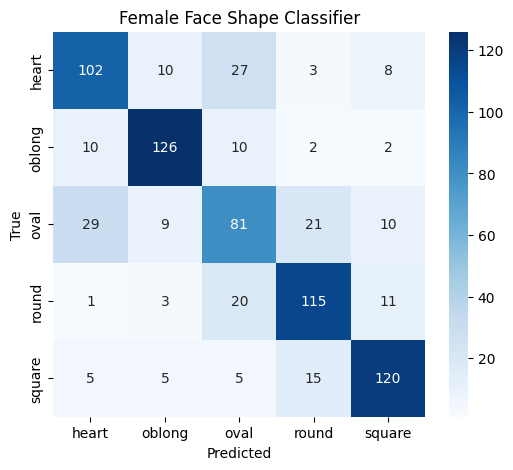

In [ ]:
test_loss, test_acc = female_shape_model.evaluate(female_test_gen)
print(f"Female shape classifier test accuracy: {test_acc:.4f}")
female_shape_model.save(os.path.join(BASE_PATH, 'female_shape_model.h5'))

evaluate_model(female_shape_model, female_test_gen, female_labels, "Female Face Shape Classifier")

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_indices = female_train_gen.class_indices
y_train_labels = female_train_gen.classes

class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weights = dict(zip(np.unique(y_train_labels), class_weights_array))

oval_idx = class_indices['oval']
class_weights[oval_idx] *= 1.5

print("Class indices:", class_indices)
print("Class weights:", class_weights)

Class indices: {'heart': 0, 'oblong': 1, 'oval': 2, 'round': 3, 'square': 4}
Class weights: {np.int64(0): np.float64(1.0014367816091954), np.int64(1): np.float64(0.998567335243553), np.int64(2): np.float64(1.5), np.int64(3): np.float64(1.0014367816091954), np.int64(4): np.float64(0.998567335243553)}


In [ ]:
female_finetune_history_2 = female_shape_model.fit(
    female_train_gen,
    validation_data=female_val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
        female_checkpoint_cb
    ]
)

Epoch 1/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.5667 - loss: 1.1781

109/109 ━━━━━━━━━━━━━━━━━━━━ 73s 640ms/step - accuracy: 0.5610 - loss: 1.1844 - val_accuracy: 0.6649 - val_loss: 0.9414
Epoch 2/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 68s 621ms/step - accuracy: 0.5836 - loss: 1.1654 - val_accuracy: 0.6595 - val_loss: 0.9116
Epoch 3/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 64s 588ms/step - accuracy: 0.5874 - loss: 1.1385 - val_accuracy: 0.6649 - val_loss: 0.9108
Epoch 4/15
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.5887 - loss: 1.1274

109/109 ━━━━━━━━━━━━━━━━━━━━ 69s 636ms/step - accuracy: 0.5968 - loss: 1.1330 - val_accuracy: 0.6756 - val_loss: 0.8914
Epoch 5/15
 72/109 ━━━━━━━━━━━━━━━━━━━━ 22s 607ms/step - accuracy: 0.6044 - loss: 1.1161

## 10. Male Face Shape Classifier

**Phase 1 (frozen base):**

In [ ]:
male_train = train_df[train_df['gender'] == 'male']
male_val = val_df[val_df['gender'] == 'male']
male_test = test_df[test_df['gender'] == 'male']
male_labels = sorted(male_train['face_shape'].unique())

print("Male classes:", male_labels)
print(f"Male train: {len(male_train)}  val: {len(male_val)}  test: {len(male_test)}")

Male classes: ['oval', 'rectangle', 'round', 'square']
Male train: 916  val: 196  test: 197


In [ ]:
male_train_gen = make_generator(male_train, 'face_shape', augment=True)
male_val_gen = make_generator(male_val, 'face_shape', shuffle=False)
male_test_gen = make_generator(male_test, 'face_shape', shuffle=False)

male_shape_model, male_base = build_transfer_model(num_classes=len(male_labels))

male_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(BASE_PATH, 'male_shape_model_checkpoint.h5'),
    save_best_only=True, monitor='val_accuracy'
)

male_history = male_shape_model.fit(
    male_train_gen,
    validation_data=male_val_gen,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
        male_checkpoint_cb
    ]
)

Found 916 validated image filenames belonging to 4 classes.
Found 196 validated image filenames belonging to 4 classes.
Found 197 validated image filenames belonging to 4 classes.
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 931ms/step - accuracy: 0.2504 - loss: 1.6285

29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.2598 - loss: 1.5573 - val_accuracy: 0.4031 - val_loss: 1.3078
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.3069 - loss: 1.4232

29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 554ms/step - accuracy: 0.3330 - loss: 1.3908 - val_accuracy: 0.4541 - val_loss: 1.2656
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.3465 - loss: 1.3282

29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 590ms/step - accuracy: 0.3679 - loss: 1.3193 - val_accuracy: 0.5612 - val_loss: 1.2198
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 585ms/step - accuracy: 0.3908 - loss: 1.2814 - val_accuracy: 0.5408 - val_loss: 1.1696
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 563ms/step - accuracy: 0.4432 - loss: 1.2292 - val_accuracy: 0.5255 - val_loss: 1.1760
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.4314 - loss: 1.2133

29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 611ms/step - accuracy: 0.4498 - loss: 1.2085 - val_accuracy: 0.5816 - val_loss: 1.1138
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.4712 - loss: 1.1741

29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 575ms/step - accuracy: 0.4672 - loss: 1.1745 - val_accuracy: 0.6276 - val_loss: 1.0801
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 577ms/step - accuracy: 0.5284 - loss: 1.1311 - val_accuracy: 0.5867 - val_loss: 1.0084
Epoch 9/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - accuracy: 0.4946 - loss: 1.1336

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 682ms/step - accuracy: 0.5284 - loss: 1.0994 - val_accuracy: 0.6531 - val_loss: 0.9662
Epoch 10/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.5172 - loss: 1.1027

29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 605ms/step - accuracy: 0.5153 - loss: 1.1013 - val_accuracy: 0.6837 - val_loss: 0.9685
Epoch 11/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 533ms/step - accuracy: 0.5686 - loss: 1.0684

29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 597ms/step - accuracy: 0.5590 - loss: 1.0692 - val_accuracy: 0.6939 - val_loss: 0.9289
Epoch 12/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 559ms/step - accuracy: 0.6026 - loss: 0.9855 - val_accuracy: 0.6684 - val_loss: 0.8971
Epoch 13/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 554ms/step - accuracy: 0.5808 - loss: 0.9846 - val_accuracy: 0.6173 - val_loss: 0.8900
Epoch 14/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 521ms/step - accuracy: 0.6015 - loss: 0.9575 - val_accuracy: 0.6888 - val_loss: 0.8471
Epoch 15/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 525ms/step - accuracy: 0.6234 - loss: 0.9440 - val_accuracy: 0.6888 - val_loss: 0.8189


**Phase 2 (fine-tune):**

In [ ]:
male_shape_model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

male_finetune_history = unfreeze_and_finetune(
    male_shape_model, male_base, male_train_gen, male_val_gen,
    unfreeze_layers=4, epochs=20,
    checkpoint_path=os.path.join(BASE_PATH, 'male_shape_model_checkpoint.h5')
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.5808 - loss: 0.9893

29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 860ms/step - accuracy: 0.5961 - loss: 0.9680 - val_accuracy: 0.6582 - val_loss: 0.8572
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.6027 - loss: 0.9668

29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 616ms/step - accuracy: 0.6266 - loss: 0.9360 - val_accuracy: 0.6786 - val_loss: 0.8172
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.5960 - loss: 0.9242

29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 783ms/step - accuracy: 0.6386 - loss: 0.8886 - val_accuracy: 0.7092 - val_loss: 0.7863
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.6752 - loss: 0.8259

29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 629ms/step - accuracy: 0.6627 - loss: 0.8476 - val_accuracy: 0.7143 - val_loss: 0.7723
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 604ms/step - accuracy: 0.6539 - loss: 0.8613 - val_accuracy: 0.6939 - val_loss: 0.7701
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 536ms/step - accuracy: 0.6801 - loss: 0.8337 - val_accuracy: 0.7092 - val_loss: 0.7314
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.6840 - loss: 0.8039

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 644ms/step - accuracy: 0.6856 - loss: 0.8152 - val_accuracy: 0.7398 - val_loss: 0.7201
Epoch 8/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 607ms/step - accuracy: 0.6823 - loss: 0.8102 - val_accuracy: 0.7245 - val_loss: 0.7198
Epoch 9/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.6727 - loss: 0.8133

29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 718ms/step - accuracy: 0.6769 - loss: 0.8341 - val_accuracy: 0.7449 - val_loss: 0.6967
Epoch 10/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.7192 - loss: 0.7395

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 693ms/step - accuracy: 0.7238 - loss: 0.7418 - val_accuracy: 0.7653 - val_loss: 0.6761
Epoch 11/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 624ms/step - accuracy: 0.7129 - loss: 0.7621 - val_accuracy: 0.7347 - val_loss: 0.6832
Epoch 12/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 705ms/step - accuracy: 0.7118 - loss: 0.7238 - val_accuracy: 0.7551 - val_loss: 0.6577
Epoch 13/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 556ms/step - accuracy: 0.7140 - loss: 0.7353 - val_accuracy: 0.7551 - val_loss: 0.6506
Epoch 14/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 548ms/step - accuracy: 0.7456 - loss: 0.6870 - val_accuracy: 0.7551 - val_loss: 0.6386
Epoch 15/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.7202 - loss: 0.6912

29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 716ms/step - accuracy: 0.7183 - loss: 0.7092 - val_accuracy: 0.7755 - val_loss: 0.6213
Epoch 16/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 625ms/step - accuracy: 0.7293 - loss: 0.7027 - val_accuracy: 0.7449 - val_loss: 0.6328
Epoch 17/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 593ms/step - accuracy: 0.7587 - loss: 0.6733 - val_accuracy: 0.7653 - val_loss: 0.6125
Epoch 18/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 550ms/step - accuracy: 0.7587 - loss: 0.6473 - val_accuracy: 0.7551 - val_loss: 0.6047
Epoch 19/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 546ms/step - accuracy: 0.7489 - loss: 0.6630 - val_accuracy: 0.7500 - val_loss: 0.6354
Epoch 20/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.7300 - loss: 0.7143

29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 702ms/step - accuracy: 0.7587 - loss: 0.6530 - val_accuracy: 0.7908 - val_loss: 0.5927


**Evaluate:**

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 880ms/step - accuracy: 0.7970 - loss: 0.5866


Male shape classifier test accuracy: 0.7970
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step
--- Male Face Shape Classifier ---
              precision    recall  f1-score   support

        oval       0.77      0.79      0.78        52
   rectangle       0.75      0.78      0.77        46
       round       0.98      0.82      0.89        51
      square       0.72      0.79      0.75        48

    accuracy                           0.80       197
   macro avg       0.80      0.80      0.80       197
weighted avg       0.81      0.80      0.80       197



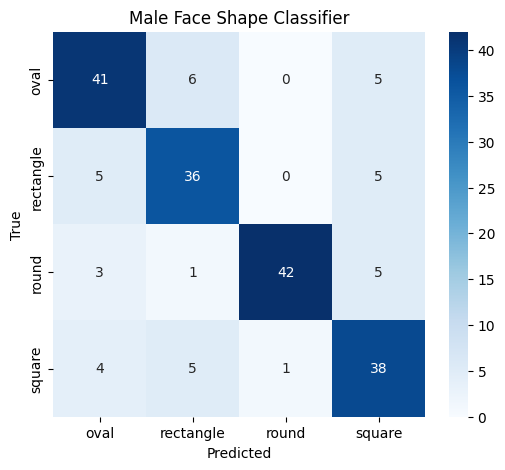

In [ ]:
test_loss, test_acc = male_shape_model.evaluate(male_test_gen)
print(f"Male shape classifier test accuracy: {test_acc:.4f}")
male_shape_model.save(os.path.join(BASE_PATH, 'male_shape_model.h5'))

evaluate_model(male_shape_model, male_test_gen, male_labels, "Male Face Shape Classifier")

In [ ]:
for layer in female_base.layers:
    print(layer.name)

input_layer_4
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


Starting GRAD Cam


In [ ]:
def make_gradcam_heatmap(img_array, model, base_model_var_name, last_conv_layer_name='block5_conv3'):
    base_model_layer = None
    for layer in model.layers:
        if 'vgg16' in layer.name.lower():
            base_model_layer = layer
            break

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [base_model_layer.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_gradcam(filepath, model, class_labels, img_size=224, alpha=0.4):
    img = cv2.cvtColor(cv2.imread(filepath), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_array = np.expand_dims(img_resized / 255., axis=0)

    heatmap, pred_idx = make_gradcam_heatmap(img_array, model, None)
    heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    overlaid = cv2.addWeighted(img_resized, 1 - alpha, heatmap_colored, alpha, 0)
    predicted_label = class_labels[pred_idx]
    return img_resized, overlaid, predicted_label

print("Grad-CAM functions ready.")

Grad-CAM functions ready.


In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3'):
    base_layer = None
    for layer in model.layers:
        if 'vgg16' in layer.name.lower():
            base_layer = layer
            break

    conv_layer = base_layer.get_layer(last_conv_layer_name)
    base_grad_model = tf.keras.models.Model(base_layer.input, [conv_layer.output, base_layer.output])

    idx = model.layers.index(base_layer)
    head_layers = model.layers[idx + 1:]

    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_output, base_output = base_grad_model(img_tensor)
        tape.watch(conv_output)
        x = base_output
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)

def overlay_gradcam(filepath, model, class_labels, img_size=224, alpha=0.4):
    img = cv2.cvtColor(cv2.imread(filepath), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (img_size, img_size))
    img_array = np.expand_dims(img_resized / 255., axis=0)

    heatmap, pred_idx = make_gradcam_heatmap(img_array, model)
    heatmap_resized = cv2.resize(heatmap, (img_size, img_size))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    overlaid = cv2.addWeighted(img_resized, 1 - alpha, heatmap_colored, alpha, 0)
    predicted_label = class_labels[pred_idx]
    return img_resized, overlaid, predicted_label

print("Grad-CAM functions ready (fixed).")

Grad-CAM functions ready (fixed).


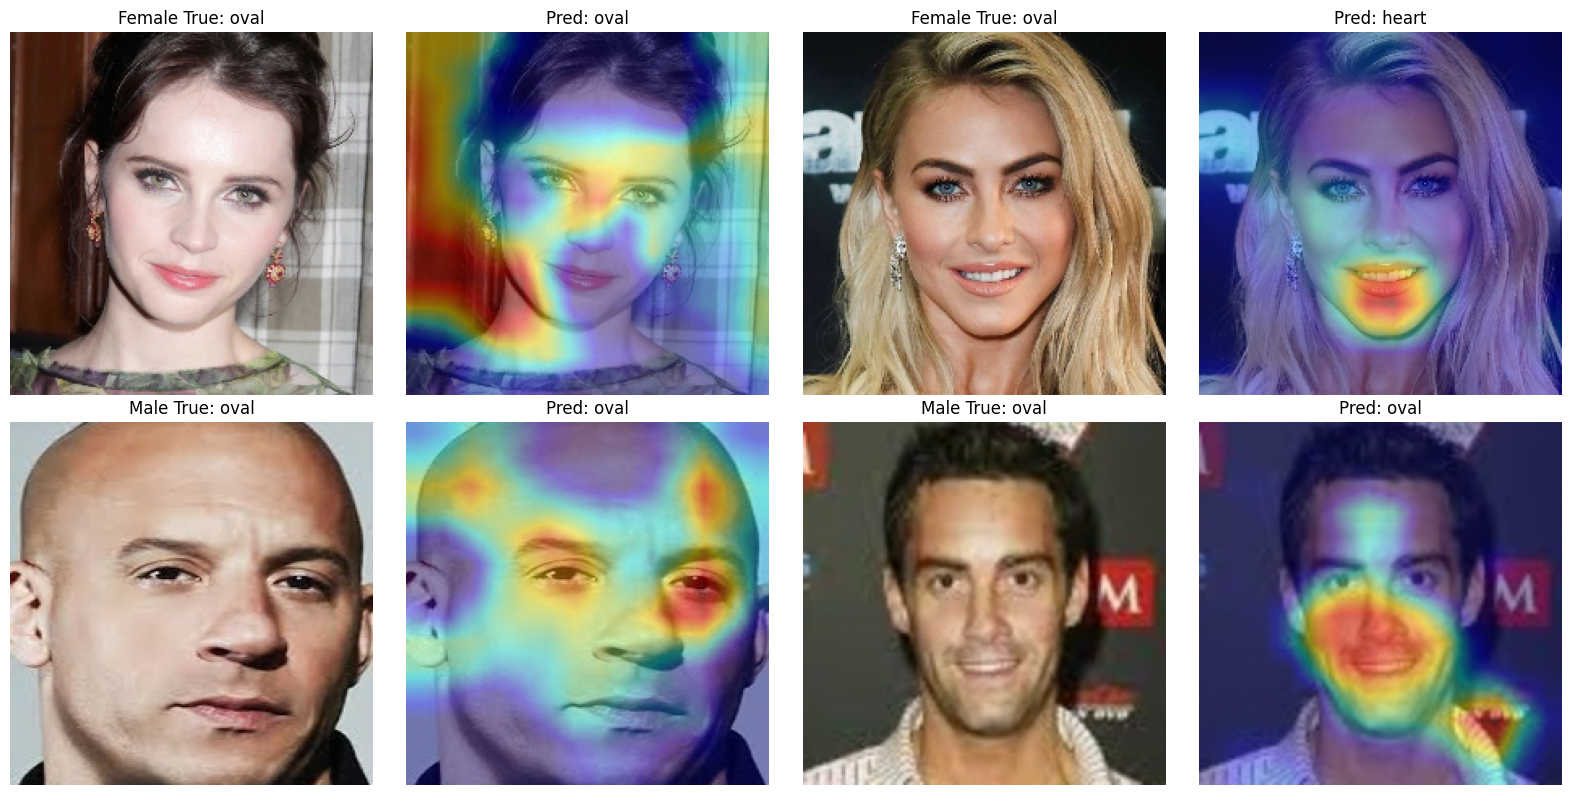

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Get a couple oval examples from each gender for direct comparison
female_oval_samples = female_test[female_test['face_shape'] == 'oval'].sample(2, random_state=1)
male_oval_samples = male_test[male_test['face_shape'] == 'oval'].sample(2, random_state=1)

for i, (_, row) in enumerate(female_oval_samples.iterrows()):
    orig, overlay, pred = overlay_gradcam(row['cropped_filepath'], female_shape_model, female_labels)
    axes[0, i*2].imshow(orig); axes[0, i*2].set_title(f"Female True: {row['face_shape']}"); axes[0, i*2].axis('off')
    axes[0, i*2+1].imshow(overlay); axes[0, i*2+1].set_title(f"Pred: {pred}"); axes[0, i*2+1].axis('off')

for i, (_, row) in enumerate(male_oval_samples.iterrows()):
    orig, overlay, pred = overlay_gradcam(row['cropped_filepath'], male_shape_model, male_labels)
    axes[1, i*2].imshow(orig); axes[1, i*2].set_title(f"Male True: {row['face_shape']}"); axes[1, i*2].axis('off')
    axes[1, i*2+1].imshow(overlay); axes[1, i*2+1].set_title(f"Pred: {pred}"); axes[1, i*2+1].axis('off')

plt.tight_layout()
plt.show()

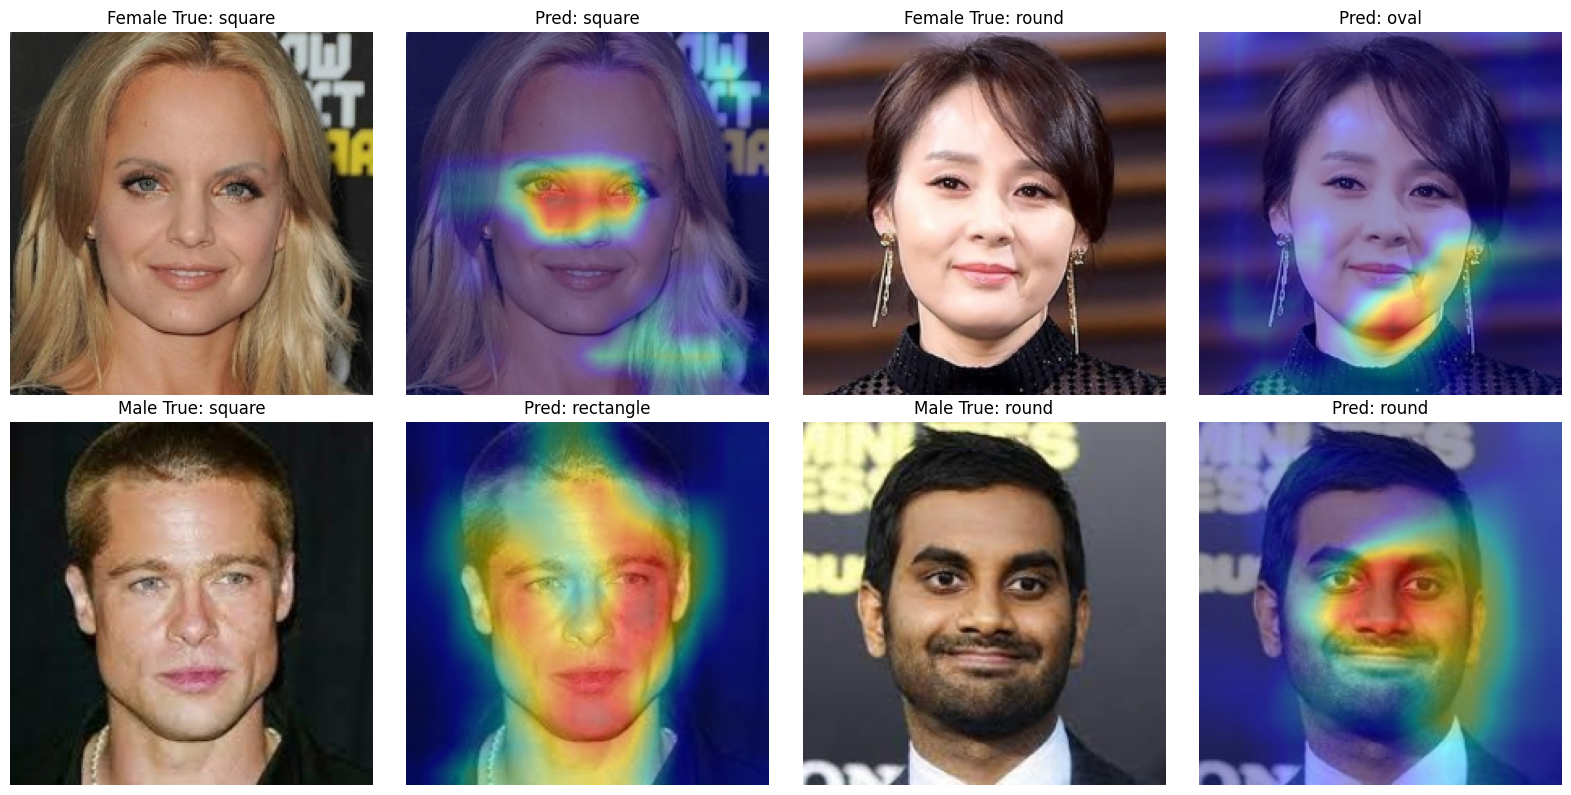

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

female_samples = pd.concat([
    female_test[female_test['face_shape'] == 'square'].sample(1, random_state=2),
    female_test[female_test['face_shape'] == 'round'].sample(1, random_state=2)
])
male_samples = pd.concat([
    male_test[male_test['face_shape'] == 'square'].sample(1, random_state=2),
    male_test[male_test['face_shape'] == 'round'].sample(1, random_state=2)
])

for i, (_, row) in enumerate(female_samples.iterrows()):
    orig, overlay, pred = overlay_gradcam(row['cropped_filepath'], female_shape_model, female_labels)
    axes[0, i*2].imshow(orig); axes[0, i*2].set_title(f"Female True: {row['face_shape']}"); axes[0, i*2].axis('off')
    axes[0, i*2+1].imshow(overlay); axes[0, i*2+1].set_title(f"Pred: {pred}"); axes[0, i*2+1].axis('off')

for i, (_, row) in enumerate(male_samples.iterrows()):
    orig, overlay, pred = overlay_gradcam(row['cropped_filepath'], male_shape_model, male_labels)
    axes[1, i*2].imshow(orig); axes[1, i*2].set_title(f"Male True: {row['face_shape']}"); axes[1, i*2].axis('off')
    axes[1, i*2+1].imshow(overlay); axes[1, i*2+1].set_title(f"Pred: {pred}"); axes[1, i*2+1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
gender_model = tf.keras.models.load_model(os.path.join(BASE_PATH, 'gender_model.h5'))
female_shape_model = tf.keras.models.load_model(os.path.join(BASE_PATH, 'female_shape_model.h5'))
male_shape_model = tf.keras.models.load_model(os.path.join(BASE_PATH, 'male_shape_model.h5'))

female_train = train_df[train_df['gender'] == 'female']
male_train = train_df[train_df['gender'] == 'male']
female_labels = sorted(female_train['face_shape'].unique())
male_labels = sorted(male_train['face_shape'].unique())

gender_train_gen = make_generator(train_df, 'gender', shuffle=False)
print("Reloaded all 3 models. Gender classes:", gender_train_gen.class_indices)

Found 4417 validated image filenames belonging to 2 classes.
Reloaded all 3 models. Gender classes: {'female': 0, 'male': 1}


In [ ]:
RECOMMENDATIONS = {
    ('female', 'oval'): {'spectacles': ['Most frame shapes work well', 'Bold geometric frames as a style statement', 'Oversized round frames'], 'hairstyle': ['Versatile — most lengths and styles suit this shape', 'Long layers', 'Side-swept bangs']},
    ('female', 'round'): {'spectacles': ['Angular or rectangular frames', 'Frames wider than the face', 'Avoid round frames (echoes shape)'], 'hairstyle': ['Height at the crown', 'Long layers past the chin', 'Side-swept fringe to elongate']},
    ('female', 'square'): {'spectacles': ['Round or oval frames', 'Thin, rimless, or semi-rimless styles'], 'hairstyle': ['Soft waves', 'Layers framing the jaw', 'Side part to soften angles']},
    ('female', 'heart'): {'spectacles': ['Bottom-heavy frames', 'Rimless or light-colored frames', 'Cat-eye styles'], 'hairstyle': ['Chin-length bobs', 'Side-swept styles', 'Volume at the jawline to balance forehead']},
    ('female', 'oblong'): {'spectacles': ['Frames with decorative or thick top rims', 'Wider frames', 'Shorter lens height'], 'hairstyle': ['Waves or curls for width', 'Blunt bangs to shorten face length', 'Avoid excessive height']},
    ('male', 'oval'): {'spectacles': ['Most frame shapes work well', 'Wayfarers', 'Classic rectangular frames'], 'hairstyle': ['Versatile — most styles suit this shape', 'Classic crew or textured crop']},
    ('male', 'round'): {'spectacles': ['Angular or rectangular frames', 'Avoid round frames'], 'hairstyle': ['Textured top with short/faded sides', 'Add height, avoid rounded silhouettes']},
    ('male', 'square'): {'spectacles': ['Round or oval frames to soften angles', 'Thin metal frames'], 'hairstyle': ['Short crop with softer fringe', 'Avoid sharp box fades that emphasize angles']},
    ('male', 'rectangle'): {'spectacles': ['Frames with decorative top rims', 'Wider frames to add visual width'], 'hairstyle': ['Fringe and side volume', 'Avoid tall pompadours that elongate further']},
}

def get_recommendation(gender, face_shape):
    return RECOMMENDATIONS.get((gender.lower(), face_shape.lower()), {'spectacles': ['No data'], 'hairstyle': ['No data']})

print(get_recommendation('female', 'round'))

{'spectacles': ['Angular or rectangular frames', 'Frames wider than the face', 'Avoid round frames (echoes shape)'], 'hairstyle': ['Height at the crown', 'Long layers past the chin', 'Side-swept fringe to elongate']}


In [ ]:
print('overlay_gradcam' in globals())
print('make_generator' in globals())
print('crop_face' in globals())

True
True
True


female - oblong
{'spectacles': ['Frames with decorative or thick top rims', 'Wider frames', 'Shorter lens height'], 'hairstyle': ['Waves or curls for width', 'Blunt bangs to shorten face length', 'Avoid excessive height']}


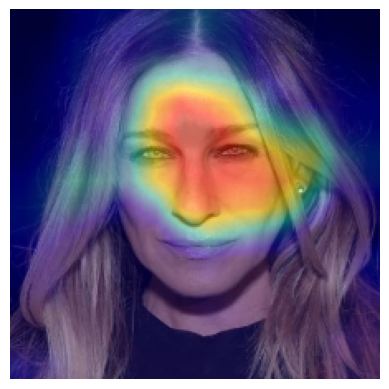

In [ ]:
GENDER_LABELS = list(gender_train_gen.class_indices.keys())

def full_pipeline(filepath):
    temp_crop = '/content/temp_crop.jpg'
    success = crop_face(filepath, temp_crop)
    if not success:
        return {'error': 'No face detected in image'}

    img = cv2.cvtColor(cv2.imread(temp_crop), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img_resized / 255., axis=0)

    gender_pred = gender_model.predict(img_array, verbose=0)
    gender_idx = np.argmax(gender_pred[0])
    gender = GENDER_LABELS[gender_idx]
    gender_confidence = float(gender_pred[0][gender_idx])

    if gender == 'female':
        shape_model, shape_labels = female_shape_model, female_labels
    else:
        shape_model, shape_labels = male_shape_model, male_labels

    _, heatmap_overlay, predicted_shape = overlay_gradcam(temp_crop, shape_model, shape_labels)
    rec = get_recommendation(gender, predicted_shape)

    return {
        'gender': gender,
        'gender_confidence': round(gender_confidence, 3),
        'face_shape': predicted_shape,
        'heatmap': heatmap_overlay,
        'recommendation': rec
    }

# Quick test on a real sample
test_result = full_pipeline(female_train.iloc[0]['filepath'])
print(test_result['gender'], '-', test_result['face_shape'])
print(test_result['recommendation'])
plt.imshow(test_result['heatmap'])
plt.axis('off')
plt.show()

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr
import tempfile

def gradio_pipeline(uploaded_image):
    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        uploaded_image.save(tmp.name)
        result = full_pipeline(tmp.name)

    if 'error' in result:
        return None, result['error']

    summary = (
        f"**Gender:** {result['gender']} (confidence: {result['gender_confidence']})\n\n"
        f"**Predicted Face Shape:** {result['face_shape']}\n\n"
        f"**Suggested Spectacles:** {', '.join(result['recommendation']['spectacles'])}\n\n"
        f"**Suggested Hairstyles:** {', '.join(result['recommendation']['hairstyle'])}"
    )
    return result['heatmap'], summary

demo = gr.Interface(
    fn=gradio_pipeline,
    inputs=gr.Image(type='pil', label='Upload a face photo'),
    outputs=[gr.Image(label='Grad-CAM Explanation'), gr.Markdown(label='Results')],
    title='Face Shape Classifier + Explainable AI',
    description='Upload a photo to get gender-conditioned face shape prediction, Grad-CAM explanation, and style recommendations.'
)

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cbb79e27069f31e07f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
